In [1]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
# import import_ipynb
from scipy.interpolate import PchipInterpolator
# import seaborn as sns

def interpolador(subject, method, size):
    # data = np.array([int(line.strip()) for line in subject.to_numpy()])  # Si lo obtienes de un DataFrame
    data = subject
    x = np.arange(len(data))
    
    # Crear 'size' puntos equidistantes
    x_new = np.linspace(0, len(data) - 1, size*(len(data)-1) + len(data))
    
    if method == 'lineal':
        data_interp = np.interp(x_new, x, data)
    elif method == 'herm':
        interpolator = PchipInterpolator(x, data)
        data_interp = interpolator(x_new)
    
    return x_new, data_interp

def interpolador_constante(subject):
    # data = np.array([int(line.strip()) for line in subject.to_numpy()])  # Si lo obtienes de un DataFrame
    x = np.arange(2)
    data_interp = np.array([])
    diferencias =np.abs(np.diff(subject))
    if (np.max(diferencias) - np.min(diferencias)) <= 1e-5:
        return subject
    diferencias_sin_0 = diferencias[diferencias != 0]
    diferencias = np.round(diferencias/np.min(diferencias_sin_0))
    for i in range(len(subject)-1):
        data = subject[i:i+2]
        if diferencias[i] == 0:
            data_interp = np.concatenate((data_interp,data[:-1]))
            continue
        size = int(diferencias[i])- 1
        # Crear 'size' puntos equidistantes
        x_new = np.linspace(0, 1, size + 2)
        interp_step = np.interp(x_new, x, data)
        data_interp = np.concatenate((data_interp,interp_step[:-1]))
    data_interp = np.concatenate((data_interp,np.array([data[-1]])))

    return data_interp

def discretizar(array, num_partitions):
    if num_partitions == 1:
        print(" Minimo de particiones: 2")
        return np.array([])
    window = (np.abs(np.min(array)) + np.abs(np.max(array)))/(num_partitions - 1)
    discretizador = [np.min(array)+window*(i) for i in range(num_partitions)]
    if discretizador[len(discretizador)-1] != np.max(array):
        discretizador[len(discretizador)-1] = np.max(array)
    array_discreto = []
    for i,valor in enumerate(array):
        array_discreto.append(min(discretizador, key=lambda x: abs(x - valor)))

    return array_discreto

def discretizar_x(array_y, num_partitions):
    if num_partitions == 1:
        print(" Minimo de particiones: 2")
        return np.array([])
    array_x = range(int(len(array_y)))
    window = (len(array_x))/(num_partitions - 1)
    x_discreto = [int(window*(i)) for i in range(num_partitions)]
    array_discreto = []
    for i in x_discreto[0:len(x_discreto)-1]:
        array_discreto.append(array_y[i])
    array_discreto.append(array_y[len(array_x)-1])

    return x_discreto, array_discreto

def arm_detector(data, num_ventanas=25, b=0.6):
    n = len(data)
    x = np.arange(n)
    
    # Calcular el tamaño de cada ventana
    window_size = n // num_ventanas

    # Lista para almacenar los porcentajes de puntos dentro de las regiones
    porcentajes = []

    # Ajustar y graficar el ajuste lineal por cada ventana con las líneas paralelas
    for i in range(0, n, window_size):
        end = i + window_size
        if end > n:
            end = n
        
        x_window = x[i:end].reshape(-1, 1)
        y_window = data[i:end]
        
        # Crear y ajustar el modelo de regresión lineal
        modelo = LinearRegression()
        modelo.fit(x_window, y_window)
        
        # Obtener la pendiente y la intersección de la recta ajustada
        pendiente = modelo.coef_[0]
        interseccion = modelo.intercept_
        
        # Predecir valores ajustados
        y_pred = modelo.predict(x_window)
                
        # Calcular las rectas paralelas desplazadas por 'b'
        y_paralela_superior = pendiente * x_window + (interseccion + b)
        y_paralela_inferior = pendiente * x_window + (interseccion - b)
                
        # Calcular el porcentaje de datos dentro de la región delimitada por las líneas paralelas
        dentro_region = np.sum((y_window >= y_paralela_inferior.flatten()) & (y_window <= y_paralela_superior.flatten()))
        fuera_region = len(y_window) - dentro_region
        
        # Calcular el porcentaje de datos dentro de la región respecto a los datos fuera de la región
        porcentaje = (dentro_region * 100)/(dentro_region + fuera_region)
        porcentajes.append(porcentaje)

    def indice_mayor_90(arr):
        n = len(arr)
    
        # Revisar cada índice para encontrar el primero que cumpla la condición
        for i in range(n):
            if np.all(arr[i:] > 80) and len(arr[i:]) > 4:
                return i
        # Si no hay tal índice, regresar el último índice
        return n - 1
    
    indice = indice_mayor_90(np.array(porcentajes))*window_size
    return indice

def J_univariante(X, tau=1, corte=False):
    X = np.array(X)
    x1 = X[tau:]
    y1 = X[:-tau]
    ff1 = np.angle(np.fft.rfft(x1))
    ff2 = np.angle(np.fft.rfft(y1))
    
    if corte:
        transition_point1 = arm_detector(ff1)
        transition_point2 = arm_detector(ff2)
        if transition_point1 != transition_point2:
            transition_point1 = transition_point2 = min(transition_point1, transition_point2)
        ff1 = ff1[:transition_point1]
        ff2 = ff2[:transition_point2]

    vectores = []
    for i in range(len(ff1) - 1):
        p1 = [ff1[i], ff2[i]]
        p2 = [ff1[i + 1], ff2[i + 1]]
        cuadrante = [
            [p2[0] - p1[0], p2[1] - p1[1]],
            [p2[0] - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
        ]
        distancias = np.array([np.linalg.norm(np.array(c) - np.array(p1)) for c in cuadrante])
        p2 = cuadrante[np.argmin(distancias)]
        vectores.append([p2[0] - p1[0], p2[1] - p1[1]])

    vectores = np.array(vectores)
    norms = np.linalg.norm(vectores, axis=1, keepdims=True)
    v_norm = np.where(norms == 0, vectores, vectores / norms)
    
    angulos = np.arccos(np.clip(np.einsum('ij,ij->i', v_norm[:-1], v_norm[1:]), -1.0, 1.0))
    cruces = np.cross(v_norm[:-1], v_norm[1:])
    angulos = np.where(cruces > 0, np.pi - angulos, angulos)
    angulos = np.where((cruces == 0) & (angulos < 0), np.pi, angulos)
    angulos = np.where(cruces < 0, angulos + np.pi, angulos)

    e = np.exp(angulos * 1j)
    e1 = np.sum(e) / len(angulos)
    J = 1.0 - np.abs(e1.real)
    
    return J, np.asarray(angulos)

def J_bivariante(X, Y, corte=False):
    X = np.array(X)
    x1 = X
    y1 = Y
    ff1 = np.angle(np.fft.rfft(x1))
    ff2 = np.angle(np.fft.rfft(y1))
    
    if corte:
        transition_point1 = arm_detector(ff1)
        transition_point2 = arm_detector(ff2)
        if transition_point1 != transition_point2:
            transition_point1 = transition_point2 = min(transition_point1, transition_point2)
        ff1 = ff1[:transition_point1]
        ff2 = ff2[:transition_point2]

    vectores = []
    for i in range(len(ff1) - 1):
        p1 = [ff1[i], ff2[i]]
        p2 = [ff1[i + 1], ff2[i + 1]]
        cuadrante = [
            [p2[0] - p1[0], p2[1] - p1[1]],
            [p2[0] - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
        ]
        distancias = np.array([np.linalg.norm(np.array(c) - np.array(p1)) for c in cuadrante])
        p2 = cuadrante[np.argmin(distancias)]
        vectores.append([p2[0] - p1[0], p2[1] - p1[1]])

    vectores = np.array(vectores)
    norms = np.linalg.norm(vectores, axis=1, keepdims=True)
    v_norm = np.where(norms == 0, vectores, vectores / norms)
    
    angulos = np.arccos(np.clip(np.einsum('ij,ij->i', v_norm[:-1], v_norm[1:]), -1.0, 1.0))
    cruces = np.cross(v_norm[:-1], v_norm[1:])
    angulos = np.where(cruces > 0, np.pi - angulos, angulos)
    angulos = np.where((cruces == 0) & (angulos < 0), np.pi, angulos)
    angulos = np.where(cruces < 0, angulos + np.pi, angulos)

    e = np.exp(angulos * 1j)
    e1 = np.sum(e) / len(angulos)
    J = 1.0 - np.abs(e1.real)
    
    return J, np.asarray(angulos)

def generar_uniforme_centrada(n, varianza):
    # Calcular el límite superior e inferior de la distribución uniforme
    limite = np.sqrt(varianza) # varianza*3
    # Generar n números aleatorios con distribución uniforme entre -limite y limite
    return np.random.uniform(-limite, limite, n)

def brownian_bridge(t0, tT, x0, xT, n_steps):
    t = np.linspace(t0, tT, n_steps)
    #Generar movimiento browniano con media cero
    W = np.random.normal(0, np.sqrt(t[1] - t[0]), size=n_steps-1)
    W = np.insert(np.cumsum(W), 0, 0)  # Inserta W(0) = 0 y suma acumulativa
    # Interpolación del Brownian Bridge
    X = x0 + (t - t0) / (tT - t0) * (xT - x0) + W - (t - t0) / (tT - t0) * W[-1]
    return t, X

def interpolador_estocastico(s_0_discreto, n_steps):
    t_list, X_list = [], []
    for i in range(len(s_0_discreto)- 1):
        t0 = i
        tT = i+1
        x0 = s_0_discreto[i]
        xT = s_0_discreto[i+1]
        t, X = brownian_bridge(t0, tT, x0, xT, n_steps)
        t_list = np.concatenate((t_list, t))
        X_list = np.concatenate((X_list, X))
    return X_list

def replace_long_repeating_segments(data, tolerance=1e-1):
    """
    Reemplaza segmentos largos de valores repetidos en los datos con un puente browniano,
    permitiendo un margen de tolerancia para determinar si los valores son similares.
    
    Args:
        data (list or array): Array de datos a procesar.
        tolerance (float): Margen de tolerancia para considerar valores como repetidos.
        
    Returns:
        list: Array con los segmentos largos reemplazados por un puente browniano.
    """
    result = []
    n = len(data)
    i = 0
    
    while i < n:
        start = i
        # Detectar si hay un segmento repetido dentro del margen de tolerancia
        while i < n - 1 and abs(data[i] - data[i + 1]) <= tolerance:
            i += 1
        
        segment_length = i - start + 1
        
        if segment_length > 2:  # Si el segmento tiene más de dos puntos repetidos
            result.append(data[start])  # Mantener el primer valor
            x0 = data[start]
            xT = data[i]
            t0, tT = 0, 1  # Intervalo estándar para el puente browniano
            
            # Generar los puntos interpolados con el puente browniano
            _, bridge = brownian_bridge(t0, tT, x0, xT, segment_length)
            result.extend(bridge[1:-1])  # Añadir los puntos generados (sin el primero ni el último)
            result.append(data[i])  # Mantener el último valor
        else:
            # Si hay uno o dos puntos repetidos, se añaden tal como están
            result.extend(data[start:i + 1])
        
        i += 1
    
    return result

def remove_consecutive_duplicates(data, tolerance=1e-1):
    """
    Remueve duplicados consecutivos en los datos con un margen de tolerancia.

    Args:
        data (list or array): Array de datos a procesar.
        tolerance (float): Margen de tolerancia para considerar valores similares.

    Returns:
        list: Array con duplicados consecutivos removidos.
    """
    if not data:
        return []

    result = [data[0]]  # Comenzamos con el primer elemento
    for i in range(1, len(data)):
        if abs(data[i] - data[i - 1]) > tolerance:
            result.append(data[i])

    return np.array(result)

def derivada_index(array):
    array = np.asarray(array)
    derivada = np.abs(np.diff(array))  # Calcula la diferencia entre puntos subsecuentes
    return derivada

def mean_d(array):
    distancias = np.abs(np.diff(array))
    return np.mean(distancias)

def graph_fases(array):
    # plt.plot(np.angle(np.fft.rfft(array)),',')
    plt.plot(np.angle(np.fft.rfft(array)),',')
    plt.title('Fases',fontsize=8)
    plt.xlabel('Frecuencias')
    plt.ylabel('Ángulos')
    plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del sistema
a = 0.1
b = 0.1
c = 9.0
dt = 0.01  # Paso de integración
transitorio = 10000  # Tiempo en pasos para eliminar el transitorio
total_puntos = 100000  # Número total de pasos

# Función del sistema de Rössler
def rossler_system(state, a, b, c):
    x, y, z = state
    dx = -y - z
    dy = x + a * y
    dz = b + z * (x - c)
    return np.array([dx, dy, dz])

# Método de Runge-Kutta de cuarto orden
def runge_kutta_step(state, dt, a, b, c):
    k1 = rossler_system(state, a, b, c)
    k2 = rossler_system(state + 0.5 * dt * k1, a, b, c)
    k3 = rossler_system(state + 0.5 * dt * k2, a, b, c)
    k4 = rossler_system(state + dt * k3, a, b, c)
    return state + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

def Rossler_generator(a,b,c,dt,transitorio,total_puntos):
    # Condición inicial
    initial_state = np.array([1.0, 1.0, 1.0])

    # Inicialización de arrays para almacenar resultados
    states = np.zeros((total_puntos, 3))
    states[0] = initial_state

    # Integración numérica
    for i in range(1, total_puntos):
        states[i] = runge_kutta_step(states[i - 1], dt, a, b, c)

    # Eliminar el transitorio
    states = states[transitorio:]

    # Extraer coordenadas x, y, z
    x, y, z = states[:, 0], states[:, 1], states[:, 2]

    # Graficar el atractor
    # fig = plt.figure(figsize=(10, 7))
    # ax = fig.add_subplot(111, projection='3d')
    # ax.plot(x, y, z, lw=0.5, color='blue')
    # ax.set_title("Atractor de Rössler", fontsize=14)
    # ax.set_xlabel("X")
    # ax.set_ylabel("Y")
    # ax.set_zlabel("Z")
    # plt.show()
    # plt.plot(x,y)

    return x,y,z


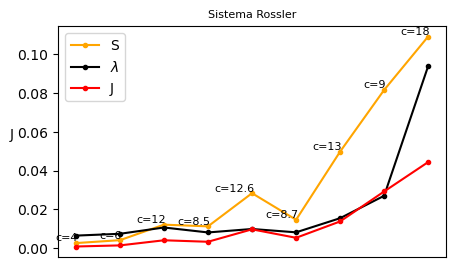

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import math
from collections import Counter

#Entropía de Shannon para res 
def entropia_shannon(x, bins=100):
    hist, _ = np.histogram(x, bins=bins)
    p = hist[hist > 0]
    p = p / np.sum(p)  
    return -np.sum(p * np.log2(p)) / np.log2(bins)

import numpy as np

def lyapunov_from_trajectory(x, y, z, dt, a=0.2, b=0.2, c=5.7):
    n = len(x)
    if not (len(y) == len(z) == n):
        raise ValueError("x, y, z deben tener la misma longitud")

    # Vector de perturbación inicial (pequeño, pero normalizado)
    delta = np.array([1e-8, 0.0, 0.0])
    delta /= np.linalg.norm(delta)

    lyap_sum = 0.0

    for i in range(n):
        # Jacobiana evaluada en (x_i, y_i, z_i)
        J = np.array([
            [0.0, -1.0, -1.0],
            [1.0, a,    0.0],
            [z[i], 0.0, x[i] - c]
        ])

        # Evolucionar perturbación linealmente: delta -> delta + dt * J * delta
        delta_new = delta + dt * J @ delta

        # Norm y renormalización
        norm = np.linalg.norm(delta_new)
        delta = delta_new / norm

        # Acumular logaritmo del crecimiento
        lyap_sum += np.log(norm)

    # Exponente de Lyapunov promedio
    return lyap_sum / (n * dt)



def entropia_permutacion(x, m=4, tau=1):
    n = len(x)
    if n < (m - 1) * tau + 1:
        return np.nan

    patrones = []
    for i in range(n - (m - 1) * tau):
        ventana = x[i:i + tau * m:tau]
        orden = tuple(np.argsort(ventana))
        patrones.append(orden)

    cuenta = Counter(patrones)
    total = sum(cuenta.values())
    p = np.array(list(cuenta.values())) / total
    H = -np.sum(p * np.log2(p))
    H_norm = H / np.log2(math.factorial(m))  # normalización
    return H_norm

#Valores de r alrededor del crítico 
c_values = [4, 6, 12, 8.5, 12.6, 8.7, 13, 9, 18] 
# c_values = [350.0, 100.5, 160.0, 99.65, 28.0]  # Valores de rho correspondientes
a = 0.1
b = 0.1
# c = 9.0
dt = 0.01  # Paso de integración
transitorio = 10000  # Tiempo en pasos para eliminar el transitorio
total_puntos = 100000 

# x,y,z = Rossler_generator(a,b,c,dt,transitorio,total_puntos)

#Cálculo de entropía de res para cada r 
entropias = []
Js = []
lyapunovs = []
for c in c_values:
    dt = 1/100
    # if c == 12:
    #     dt = 1/1000
    # # if c == 18:
    #     # dt = 1/14
    # if c in [8.5,12.6]:
    #     dt = 1/200
    serie, serie_y, serie_z = Rossler_generator(a,b,c,dt,transitorio,total_puntos)
    # serie = lorenz_generator(c, dt, transitorio, total_puntos)[0]
    J,alphas = J_univariante(serie)
    lyapunov = lyapunov_from_trajectory(serie,serie_y,serie_z,dt,a,b,c)
    res = np.abs(np.diff(alphas))
    if len(res) == 0 or np.any(np.isnan(res)):
        entropias.append(0)  # o np.nan
        continue
    ent = entropia_shannon(np.diff(alphas))
    entropias.append(ent)
    Js.append(J)
    lyapunovs.append(lyapunov)

# === Graficar resultado ===
fig = plt.subplots(figsize=(5,3))
plt.ylabel('J',rotation=360,fontsize=10)
plt.plot(entropias, color='orange', marker='.', linestyle='-', label='S')
plt.plot(lyapunovs, color='black', marker='.', linestyle='-', label=r'$\lambda$')
plt.plot(Js, color='red', marker='.', linestyle='-', label='J')
plt.legend()
plt.xlabel('Parámetro c')
# plt.ylabel('S ó J')
# plt.ylim(0,1.0)
plt.gca().axes.get_xaxis().set_visible(False)
plt.title('Sistema Rossler', fontsize=8)

# Añadir etiquetas
for i, (x, c) in enumerate(zip(range(len(c_values)), c_values)):
    plt.text(x+0.05, entropias[i], f'c={c}', fontsize=8, ha='right', va='bottom')

plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del sistema
sigma = 10.0  # Parámetro sigma
beta = 8.0 / 3.0  # Parámetro beta
rho = 350.0  # Parámetro rho
dt = 0.01  # Paso de integración
transitorio = 15000  # Tiempo en pasos para eliminar el transitorio
total_puntos = 100000  # Número total de pasos

# Función del sistema de Lorenz
def lorenz_system(state, sigma, beta, rho):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz])

# Método de Runge-Kutta de cuarto orden
def runge_kutta_step(state, dt, sigma, beta, rho):
    k1 = lorenz_system(state, sigma, beta, rho)
    k2 = lorenz_system(state + 0.5 * dt * k1, sigma, beta, rho)
    k3 = lorenz_system(state + 0.5 * dt * k2, sigma, beta, rho)
    k4 = lorenz_system(state + dt * k3, sigma, beta, rho)
    return state + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

def lorenz_generator(rho, dt, transitorio, total_puntos, sigma = 10.0, beta=8.0/3.0):
    # Condición inicial
    initial_state = np.array([1.0, 1.0, 1.0])

    # Inicialización de arrays para almacenar resultados
    states = np.zeros((total_puntos, 3))
    states[0] = initial_state

    # Integración numérica
    for i in range(1, total_puntos):
        states[i] = runge_kutta_step(states[i - 1], dt, sigma, beta, rho)

    # Eliminar el transitorio
    states = states[transitorio:]

    # Extraer coordenadas x, y, z
    x, y, z = states[:, 0], states[:, 1], states[:, 2]

    # Graficar el atractor
    # fig = plt.figure(figsize=(10, 7))
    # ax = fig.add_subplot(111, projection='3d')
    # ax.plot(x, y, z, lw=0.5, color='red')
    # ax.set_title("Atractor de Lorenz", fontsize=14)
    # ax.set_xlabel("X")
    # ax.set_ylabel("Y")
    # ax.set_zlabel("Z")
    # plt.show()
    # plt.plot(x,y)
    # plt.show()

    return x, y, z


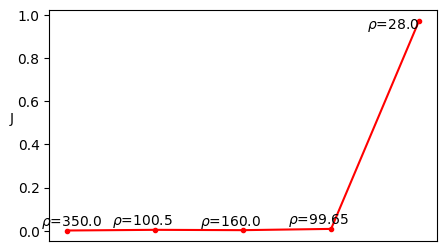

In [34]:
rho_values = [350.0, 100.5, 160.0, 99.65, 28.0]  # Valores de c correspondientes
Js_lorenz = [0.0007187192258479858,
 0.0038119615033079812,
 0.0023211682251085275,
 0.008150909636839954,
 0.9749492743626907]
# Graficar
fig = plt.subplots(figsize=(5,3))
plt.plot(Js_lorenz, color='red', marker='.', linestyle='-', label='Índice J')
plt.xlabel(r'Parámetro $\rho$')
plt.ylabel('J',rotation=360,fontsize=10)
# plt.title('Sistema Lorenz', fontsize=8)

# Añadir etiquetas
plt.text(0.4, Js_lorenz[0], fr'$\rho$={rho_values[0]}', fontsize=10, ha='right', va='bottom')
for i, (x, c) in enumerate(zip(range(len(rho_values)-2), rho_values[1:-1])):
    plt.text(x+1+0.2, Js_lorenz[i+1], fr'$\rho$={c}', fontsize=10, ha='right', va='bottom')
plt.text(4.0, Js_lorenz[4]-0.06, fr'$\rho$={rho_values[4]}', fontsize=10, ha='right', va='bottom')
plt.gca().axes.get_xaxis().set_visible(False)
plt.show()

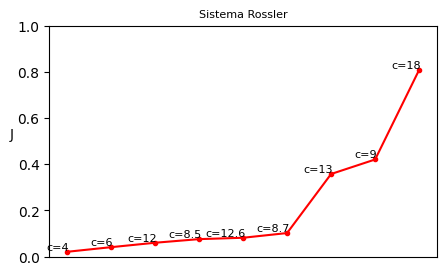

In [38]:
c_values = [4, 6, 12, 8.5, 12.6, 8.7, 13, 9, 18]  # Valores de c correspondientes
Js_rossler = [0.0203,
 0.0403,
 0.0595,
 0.0752,
 0.0811,
 0.1015,
 0.35713,
 0.42,
 0.8079997579775595]
# Graficar
fig = plt.subplots(figsize=(5,3))
plt.ylabel('J',rotation=360,fontsize=10)
plt.plot(Js_rossler, color='red', marker='.', linestyle='-', label='Índice J')
plt.xlabel('Parámetro c')
plt.ylabel('J')
plt.ylim(0,1.0)
plt.gca().axes.get_xaxis().set_visible(False)
plt.title('Sistema Rossler', fontsize=8)

# Añadir etiquetas
for i, (x, c) in enumerate(zip(range(len(c_values)), c_values)):
    plt.text(x+0.05, Js_rossler[i], f'c={c}', fontsize=8, ha='right', va='bottom')

plt.show()

In [ ]:
## x es una serie de tiempo
frequencies = np.arange(0, len(np.fft.rfft(x)))/(len(x)*0.01)
fases = np.angle(np.fft.rfft(x))
pot = (np.abs(np.fft.rfft(x))/len(x))**2


plt.plot(frequencies,fases,",")
plt.axvline(x=4,ls='--',color='red')
plt.legend(loc='lower right',fontsize=7)
plt.xlabel('f')
plt.ylabel('Ángulo de fase')
plt.show()


plt.plot(frequencies,pot,",")
# plt.legend(loc='upper right',fontsize=7)
plt.axvline(x=4,ls='--',color='red')
plt.yscale('log')
# plt.grid()
plt.xlabel('f')
plt.ylabel('Potencia')
plt.show()